<a href="https://colab.research.google.com/github/IssarapongB/BasicPython/blob/main/99424_LAB_ACTIVITY3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
mydata = pd.read_excel("/content/drive/MyDrive/99424_1/condo.xlsx")
mydata.head(4)

,AREA,BEDROOM,BATHROOM,SIZE,FLOOR,BTS,MRT,SELL_PRICE
0,rama9,2,2,101.0,12,n,y,10500000
1,rama9,3,3,103.0,17,n,y,10900000
2,rama9,1,1,63.6,7,n,y,5490000
3,rama9,1,1,22.0,20,y,y,3300000


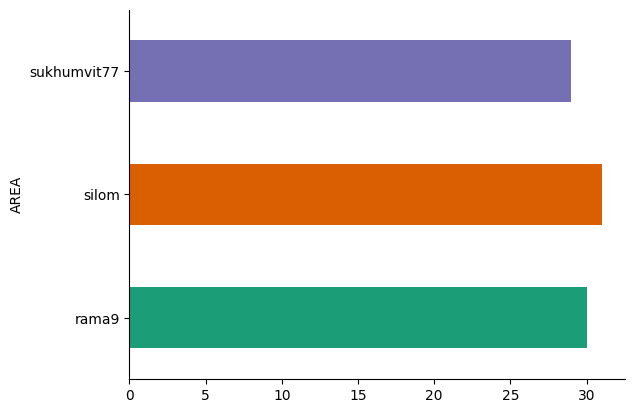

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
mydata.groupby('AREA').size().plot(kind='barh',
 color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AREA        90 non-null     object 
 1   BEDROOM     90 non-null     int64  
 2   BATHROOM    90 non-null     int64  
 3   SIZE        90 non-null     float64
 4   FLOOR       90 non-null     int64  
 5   BTS         90 non-null     object 
 6   MRT         90 non-null     object 
 7   SELL_PRICE  90 non-null     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 5.8+ KB


In [ ]:
isObject=[name for name in mydata.columns if
          mydata[name].dtype =='object']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in list(isObject):
  mydata[i]=le.fit_transform(mydata[i])
for x in isObject:
  print(x," = ",mydata[x].unique())

AREA  =  [0 1 2]
BTS  =  [0 1]
MRT  =  [1 0]


In [59]:
cor = mydata.corr()
corr_price=cor["SELL_PRICE"].sort_values(ascending=False)
print(corr_price)

SELL_PRICE    1.000000
SIZE          0.847275
BEDROOM       0.576384
FLOOR         0.532892
BATHROOM      0.486580
BTS           0.129338
AREA         -0.000365
MRT          -0.085424
Name: SELL_PRICE, dtype: float64


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 3.7.1. กำหนดให้ตัวแปร X เก็บข้อมูล 3 คุณลักษณะ
X = mydata[['SIZE', 'BEDROOM', 'FLOOR']]

# 3.7.2. 定義กำหนดให้ตัวแปร y เก็บข้อมูล SELL_Price
y = mydata['SELL_PRICE']

# 3.7.3. แบ่งข้อมูลเป็น 80:20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=0)

# 3.7.4. สร้างตัวแปร model ชื่อว่า mymodelLR
mymodelLR = LinearRegression()
mymodelLR.fit(X_train, y_train)

LinearRegression()

In [100]:
coeff1 = pd.DataFrame(mymodelLR.coef_, X.columns, columns=['Coefficient'])
coeff1

,Coefficient
SIZE,4.336291e+05
BEDROOM,-1.136897e+07
FLOOR,3.502551e+05


In [101]:
# 1. ใช้ X_test (X พิมพ์ใหญ่) ให้ตรงกับตอนแบ่งข้อมูลในข้อ 3.7
y_predicted = mymodelLR.predict(X_test)

# 2. นำข้อมูลใส่ DataFrame โดยตรง (ห้ามใส่ [] ครอบตัวแปรเด็ดขาด)
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_predicted})

# 3. สั่งพิมพ์ตารางออกมาดูแบบแยกแถวสวยงาม
print(df)

       Actual     Predicted
2     5490000  1.609901e+07
13    4650000  3.797352e+06
53    5400000  2.551839e+06
41   14500000  2.184854e+07
66    5990000  1.312059e+07
30   15500000  7.949372e+06
45   15000000  1.923001e+07
43  229000000  1.233661e+08
78    2990000  3.980860e+06
89   13500000  6.204379e+06
7     3800000  7.216529e+06
26    2990000  7.266385e+06
33    7489000  1.263689e+07
63    1190000 -1.156074e+06
8     5400000  8.250535e+06
16    5990000  8.372524e+06
24    1900000 -2.390347e+06
56   13800000  1.905774e+07
77    2830000  5.685209e+06
42    8557000  1.775728e+07
22    1920000  7.451898e+05
6     5300000  1.255373e+07
61    2300000 -7.772466e+05
48   10400000  2.518743e+06
80    1990000 -1.339581e+06
54   14790000  1.833475e+07
73    7100000  8.055787e+06


In [102]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# คำนวณหาค่าประสิทธิภาพ
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
r2 = r2_score(y_test, y_predicted) # แก้ไขไม่ให้ชื่อตัวแปรซ้ำกับชื่อฟังก์ชัน

print('The intercept is:', mymodelLR.intercept_)
print('The coefficient is:', mymodelLR.coef_)
print('The rmse is:', rmse)
print('The r2_score is:', r2)

The intercept is: -2562612.80667392
The coefficient is: [   433629.06241227 -11368970.65272258    350255.08272618]
The rmse is: 20974973.35562135
The r2_score is: 0.7527612942370545


In [103]:
Accuracy=r2_score(y_test,y_predicted)*100
print(" Accuracy of the model is %.2f" %Accuracy)

 Accuracy of the model is 75.28


In [107]:
X1 = 40  # size
X2 = 1   # bedroom
X3 = 6   # floor

def predictSellingPrice():
    a = -2562612.80667392
    b1 = 433629.06241227
    b2 = -11368970.65272258
    b3 = 350255.08272618
    error = 0
    Y = a + np.sum(b1*X1) + np.sum(b2*X2) + np.sum(b3*X3) + 0
    print(Y)

predictSellingPrice()

5515109.533451378


In [106]:
X1 = 100  # size
X2 = 2    # bedroom
X3 = 20   # floor

def predictSellingPrice():
    a = -2562612.80667392
    b1 = 433629.06241227
    b2 = -11368970.65272258
    b3 = 350255.08272618
    error = 0
    Y = a + np.sum(b1*X1) + np.sum(b2*X2) + np.sum(b3*X3) + 0
    print(Y)

predictSellingPrice()

25067453.78363152


In [108]:
import pandas as pd

# 1. สร้างตารางข้อมูลห้องใหม่ที่โจทย์ต้องการให้ทำนาย
new_condos = pd.DataFrame({
    'SIZE': [40, 100],
    'BEDROOM': [1, 2],
    'FLOOR': [6, 20]
})

# 2. ใช้โมเดลทำนายราคาออกมา
predicted_prices = mymodelLR.predict(new_condos)

# 3. แสดงผลลัพธ์ราคาทำนายตามลำดับ
for i, price in enumerate(predicted_prices):
    print(f"ราคาทำนายของห้องคอนโดแบบที่ {i+1} = {price:,.2f} บาท")

ราคาทำนายของห้องคอนโดแบบที่ 1 = 5,515,109.53 บาท
ราคาทำนายของห้องคอนโดแบบที่ 2 = 25,067,453.78 บาท
